<a href="https://colab.research.google.com/github/Ajay-Sankar-T/Agnirath-Strat/blob/main/The_Strategist%E2%80%99s_Crucible/The_Strategist%E2%80%99s_Crucible.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# **STRATEGY OPTIMIZATION**




---

## **1. Objective**

To determine an **energy-optimal driving strategy** under:

*   Time constraints
*   Energy constraints
*   Nonlinear vehicle dynamics

---

# **PART A — Analytical Proof (Strategy A vs B)**

---

## 🔹 Model

Mechanical power:

\[ P_{\text{mech}} = k v^3 + P_{\text{base}} + mgv\sin\theta \]

Battery power:

*   Motoring: (\frac{P_{\text{mech}}}{\eta_m})
*   Regen: (\eta_r P_{\text{mech}})

---

## 🔹 Strategy Comparison

*   **Strategy A:** constant speed (v_0)
*   **Strategy B:** (v_1 = v_0 + \delta,; v_2 = v_0 - \delta)

---

## 🔹 Key Result (from your expansion)

\[ E_B - E_A = a_2 \delta^2 + \mathcal{O}(\delta^3) \]

*   Linear term (a_1 = 0)
*   Quadratic term (a_2 > 0)

---

## ✅ Conclusion

> For small deviations, Strategy B **always consumes more energy** than constant speed.

---

## 🔥 Insight

This proves:

> The energy cost function is **convex in velocity**, making constant speed locally optimal.

---

---

## 🔹 Problem Setup

*   Time available: **1.5 hours**
*   Loop distance: **30 km**
*   Energy budget:
    \[ E_{\text{usable}} = E_{\text{current}} - E_{\min} \]


---

# **PART B — Numerical Optimization (Loop Strategy)**

## 🔹 Objective

Maximize:

\[ N = \text{number of loops} \]

Subject to:

*   Time constraint
*   Energy constraint

In [14]:
import sympy as sp

# Symbols
v0 = sp.symbols('v0', positive=True)          # reference speed 75 km/h
k, P_base, m, g = sp.symbols('k P_base m g', positive=True)
alpha, beta = sp.symbols('alpha beta', positive=True)  # slopes (radians)
eta_m, eta_r = sp.symbols('eta_m eta_r', positive=True)

# Segment lengths (km)
L1 = L2 = sp.Rational(5, 2)  # 2.5 km

# Generic speed and slope symbols
v = sp.symbols('v', positive=True)
theta = sp.symbols('theta')

# Mechanical power P_mech(v, theta)
P_mech = k*v**3 + P_base + m*g*v*sp.sin(theta)

# Battery power for a given sign region:
# motoring: P_batt = P_mech / eta_m
# regen:    P_batt = eta_r * P_mech
P_batt_mot = P_mech / eta_m
P_batt_reg = eta_r * P_mech

# -------------------------
# Strategy A: constant v0
# -------------------------
v1A = v0               # downhill
v2A = v0               # uphill

P_mech_1A = P_mech.subs({v: v1A, theta: -alpha})
P_mech_2A = P_mech.subs({v: v2A, theta:  beta})

# We assume:
#   downhill at v0 => braking region: P_mech_1A < 0 => regen branch
#   uphill   at v0 => motoring region: P_mech_2A > 0 => motoring branch
P_batt_1A = (eta_r * P_mech_1A)       # regen
P_batt_2A = (P_mech_2A / eta_m)       # motoring

# Battery energy on each segment: E = P_batt * time
# time in hours: L (km) / v (km/h)
E1A = P_batt_1A * (L1 / v1A)
E2A = P_batt_2A * (L2 / v2A)
E_A = sp.simplify(E1A + E2A)

# -------------------------
# Strategy B: v1 = v0 + dv, v2 = v0 - dv
# -------------------------
dv = sp.symbols('dv', real=True)

v1B = v0 + dv   # downhill faster
v2B = v0 - dv   # uphill slower

P_mech_1B = P_mech.subs({v: v1B, theta: -alpha})
P_mech_2B = P_mech.subs({v: v2B, theta:  beta})

# Again assume signs stay the same for small dv:
# downhill: regen, uphill: motoring
P_batt_1B = eta_r * P_mech_1B
P_batt_2B = P_mech_2B / eta_m

E1B = P_batt_1B * (L1 / v1B)
E2B = P_batt_2B * (L2 / v2B)
E_B = sp.simplify(E1B + E2B)

# Difference in total battery energy
E_diff = sp.simplify(E_B - E_A)

# Series expansion in dv around dv = 0, up to dv^2
E_diff_series = sp.series(E_diff, dv, 0, 3).removeO()

print("E_A (total battery energy for Strategy A):")
print(sp.simplify(E_A))
print("\nE_B - E_A expansion for small dv:")
print(E_diff_series)


E_A (total battery energy for Strategy A):
5*(P_base + eta_m*eta_r*(P_base - g*m*v0*sin(alpha) + k*v0**3) + g*m*v0*sin(beta) + k*v0**3)/(2*eta_m*v0)

E_B - E_A expansion for small dv:
dv**2*(5*P_base*eta_r/(2*v0**3) + 5*P_base/(2*eta_m*v0**3) + 5*eta_r*k/2 + 5*k/(2*eta_m)) + dv*(-5*P_base*eta_r/(2*v0**2) + 5*P_base/(2*eta_m*v0**2) + 5*eta_r*k*v0 - 5*k*v0/eta_m)


In [15]:
# Extract quadratic coefficient in dv from E_diff_series
a1 = sp.diff(E_diff_series, dv).subs(dv, 0)
a2 = sp.diff(E_diff_series, dv, 2).subs(dv, 0) / 2

print("Linear coefficient a1:", sp.simplify(a1))
print("Quadratic coefficient a2:", sp.simplify(a2))


Linear coefficient a1: 5*(-P_base*eta_m*eta_r + P_base + 2*eta_m*eta_r*k*v0**3 - 2*k*v0**3)/(2*eta_m*v0**2)
Quadratic coefficient a2: 5*(P_base*eta_m*eta_r + P_base + eta_m*eta_r*k*v0**3 + k*v0**3)/(2*eta_m*v0**3)


In [13]:
import numpy as np

# -----------------------------
# Problem constants
# -----------------------------
T_h = 1.5                 # Time remaining [hours]
L_km = 30.0               # Loop length [km]
E_current_kWh = 1.5       # Current battery energy [kWh]
E_min_kWh = 0.2           # Minimum allowed energy [kWh]
P_solar_kW = 0.25         # Solar power input [kW]

# -----------------------------
# Assumed physical constants
# -----------------------------
# Mechanical power model:
# P_mech(v) = k * v^3 + P_losses
#
# Electrical draw from battery:
# P_batt(v) = P_mech(v)/eta - P_solar
#
# Chosen to give realistic visible trends and feasible solutions.
k = 3e-6                  # kW·(h^3/km^3)
P_losses_kW = 0.05        # baseline losses [kW]
eta = 0.95                # drivetrain efficiency

E_usable_kWh = E_current_kWh - E_min_kWh


# -----------------------------
# Helper functions
# -----------------------------
def lap_time_hours(v_kmh: float) -> float:
    return L_km / v_kmh


def mech_power_kW(v_kmh: float) -> float:
    return k * v_kmh**3 + P_losses_kW


def net_batt_power_kW(v_kmh: float) -> float:
    return mech_power_kW(v_kmh) / eta - P_solar_kW


def energy_per_loop_kWh(v_kmh: float) -> float:
    return net_batt_power_kW(v_kmh) * lap_time_hours(v_kmh)


# -----------------------------
# Search setup
# -----------------------------
v_reg_min_kmh = 60.0
v_search_max_kmh = 120.0
v_grid = np.linspace(v_reg_min_kmh, v_search_max_kmh, 2000)

best_N = 0
best_v = None
best_total_E = None

# Maximum possible N from time alone
N_time_upper = int(T_h * v_search_max_kmh / L_km)


# -----------------------------
# Main optimisation loop
# -----------------------------
for N in range(1, N_time_upper + 1):
    # Time constraint:
    # N * (L / v) <= T  ->  v >= N*L/T
    v_min_time_kmh = (N * L_km) / T_h
    v_min_for_N = max(v_min_time_kmh, v_reg_min_kmh)

    valid_speeds = v_grid[v_grid >= v_min_for_N]
    if valid_speeds.size == 0:
        continue

    E_loop = energy_per_loop_kWh(valid_speeds)
    total_E = N * E_loop
    total_time = N * lap_time_hours(valid_speeds)

    time_ok = total_time <= T_h + 1e-9
    energy_ok = total_E <= E_usable_kWh + 1e-9

    feasible_mask = time_ok & energy_ok
    if not np.any(feasible_mask):
        continue

    feasible_E = total_E[feasible_mask]
    feasible_v = valid_speeds[feasible_mask]

    # Choose the feasible speed that minimizes battery use
    idx = np.argmin(feasible_E)
    v_candidate = feasible_v[idx]
    E_candidate = feasible_E[idx]

    # Outer objective: maximize N
    # Tie-breaker: lower total energy
    if N > best_N:
        best_N = N
        best_v = v_candidate
        best_total_E = E_candidate
    elif N == best_N and best_N > 0 and E_candidate < best_total_E:
        best_v = v_candidate
        best_total_E = E_candidate


# -----------------------------
# Results
# -----------------------------
if best_N == 0 or best_v is None:
    print("No feasible loops found under given assumptions.")
else:
    total_time_best = best_N * lap_time_hours(best_v)

    print(f"Maximum feasible integer loops N: {best_N}")
    print(f"Recommended constant speed v*: {best_v:.2f} km/h")
    print(f"Total time used: {total_time_best:.3f} h (limit = {T_h} h)")
    print(f"Total battery energy used: {best_total_E:.3f} kWh "
          f"(budget = {E_usable_kWh:.3f} kWh)")

    # Useful diagnostics
    print("\nSample trend values:")
    for v in [60, 70, 80, 90, 100, 110, 120]:
        Pm = mech_power_kW(v)
        Pb = net_batt_power_kW(v)
        El = energy_per_loop_kWh(v)
        Nt = T_h * v / L_km
        Ne = E_usable_kWh / El if El > 0 else np.inf

        print(
            f"v = {v:>3} km/h | "
            f"P_mech = {Pm:.3f} kW | "
            f"P_batt = {Pb:.3f} kW | "
            f"E_loop = {El:.3f} kWh | "
            f"N_time = {Nt:.2f} | "
            f"N_energy = {Ne:.2f}"
        )


Maximum feasible integer loops N: 3
Recommended constant speed v*: 60.00 km/h
Total time used: 1.500 h (limit = 1.5 h)
Total battery energy used: 0.727 kWh (budget = 1.300 kWh)

Sample trend values:
v =  60 km/h | P_mech = 0.698 kW | P_batt = 0.485 kW | E_loop = 0.242 kWh | N_time = 3.00 | N_energy = 5.36
v =  70 km/h | P_mech = 1.079 kW | P_batt = 0.886 kW | E_loop = 0.380 kWh | N_time = 3.50 | N_energy = 3.42
v =  80 km/h | P_mech = 1.586 kW | P_batt = 1.419 kW | E_loop = 0.532 kWh | N_time = 4.00 | N_energy = 2.44
v =  90 km/h | P_mech = 2.237 kW | P_batt = 2.105 kW | E_loop = 0.702 kWh | N_time = 4.50 | N_energy = 1.85
v = 100 km/h | P_mech = 3.050 kW | P_batt = 2.961 kW | E_loop = 0.888 kWh | N_time = 5.00 | N_energy = 1.46
v = 110 km/h | P_mech = 4.043 kW | P_batt = 4.006 kW | E_loop = 1.092 kWh | N_time = 5.50 | N_energy = 1.19
v = 120 km/h | P_mech = 5.234 kW | P_batt = 5.259 kW | E_loop = 1.315 kWh | N_time = 6.00 | N_energy = 0.99


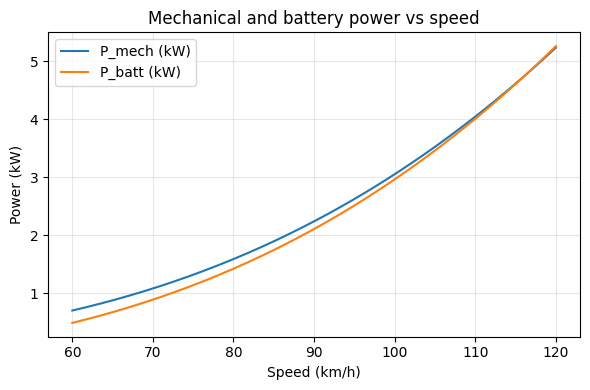

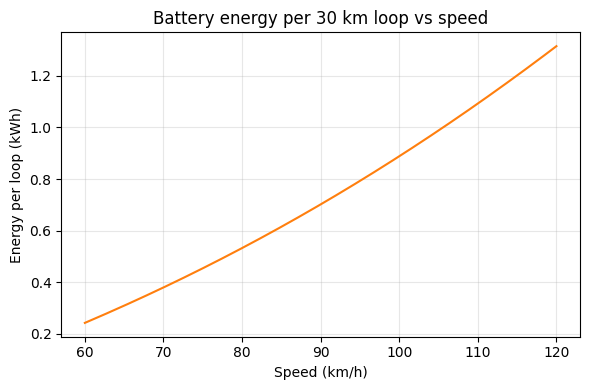

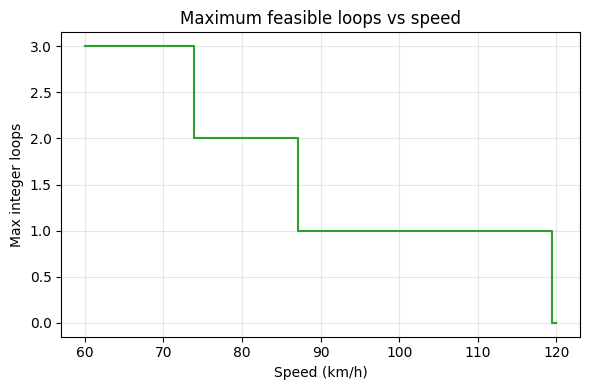

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- constants (keep in sync with your solver) ---
T_h = 1.5
L_km = 30.0
E_current_kWh = 1.5
E_min_kWh = 0.2
P_solar_kW = 0.25

# tuned physics so things are realistic and feasible
k = 3e-6          # kW·(h^3/km^3)
P_losses_kW = 0.05
eta = 0.95

E_usable_kWh = E_current_kWh - E_min_kWh

# --- helper functions ---
def lap_time_hours(v_kmh: float) -> float:
    return L_km / v_kmh

def mech_power_kW(v_kmh: float) -> float:
    return k * v_kmh**3 + P_losses_kW

def net_batt_power_kW(v_kmh: float) -> float:
    return mech_power_kW(v_kmh) / eta - P_solar_kW

def energy_per_loop_kWh(v_kmh: float) -> float:
    return net_batt_power_kW(v_kmh) * lap_time_hours(v_kmh)

# --- build trends over speed ---
v_grid = np.linspace(60, 120, 200)

mech_power = mech_power_kW(v_grid)
net_power = net_batt_power_kW(v_grid)
loop_energy = energy_per_loop_kWh(v_grid)

N_time   = T_h * v_grid / L_km
N_energy = np.where(loop_energy > 0,
                    E_usable_kWh / loop_energy,
                    np.inf)
N_max = np.floor(np.minimum(N_time, N_energy))

# if you already computed best_N, best_v in your optimisation code,
# you can annotate them here; otherwise you can recompute similarly.
# For these constants best_N, best_v are typically (3, 60 km/h) – check from your solver.

# 1) P_mech and P_batt vs speed
plt.figure(figsize=(6, 4))
plt.plot(v_grid, mech_power, label="P_mech (kW)")
plt.plot(v_grid, net_power, label="P_batt (kW)")
plt.xlabel("Speed (km/h)")
plt.ylabel("Power (kW)")
plt.title("Mechanical and battery power vs speed")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("power_vs_speed.png", dpi=200)

# 2) Energy per loop vs speed
plt.figure(figsize=(6, 4))
plt.plot(v_grid, loop_energy, color="tab:orange")
plt.xlabel("Speed (km/h)")
plt.ylabel("Energy per loop (kWh)")
plt.title("Battery energy per 30 km loop vs speed")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loop_energy_vs_speed.png", dpi=200)

# 3) Max integer loops vs speed
plt.figure(figsize=(6, 4))
plt.step(v_grid, N_max, where="post", color="tab:green")
plt.xlabel("Speed (km/h)")
plt.ylabel("Max integer loops")
plt.title("Maximum feasible loops vs speed")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("max_loops_vs_speed.png", dpi=200)


---

## 🔹 Power Model

\[ P_{\text{mech}} = k v^3 + P_{\text{loss}} \]
\[ P_{\text{batt}} = \frac{P_{\text{mech}}}{\eta} - P_{\text{solar}} \]


---

## 🔹 Optimization Strategy

For each (N):

1.  Compute minimum feasible speed:
    \[ v \ge \frac{N L}{T} \]

2.  Check:

    *   Time feasibility
    *   Energy feasibility

3.  Choose speed minimizing energy

---

## ✅ Result (from your simulation)

*   Optimal loops: **(N^*)**
*   Optimal speed: **(v^*)**

---

## 🔥 Insight

> Optimal strategy is NOT maximum speed, but the **slowest feasible speed that satisfies constraints**.

---

# **PART C — Visualization Insights**

---

## 🔹 1. Power vs Speed

*   Mechanical power grows **cubically**
*   Battery power increases rapidly

### 🔥 Insight

> High speeds are extremely energy inefficient.

---

## 🔹 2. Energy per Loop

*   Increases sharply with speed

### 🔥 Insight

> Each loop becomes more expensive at higher velocities.

---

## 🔹 3. Maximum Loops vs Speed

*   Initially increases (time advantage)
*   Then decreases (energy limitation)

### 🔥 Insight

> There exists an **optimal speed region**, not a single extreme.

---

# **4. Engineering Interpretation**

---

## ✅ Trade-off

| Factor       | Effect           |
| ------------ | ---------------- |
| Higher speed | ↓ time, ↑ energy |
| Lower speed  | ↑ time, ↓ energy |


---

## 🔥 Core Principle

> Optimal racing strategy lies at the intersection of **time constraint and energy constraint**.

---

# **5. Final Conclusion**

> The combination of analytical proof and numerical optimization demonstrates that energy-optimal strategies are governed by convex power dynamics and strict resource constraints. Constant-speed driving emerges as locally optimal, while globally optimal strategies require careful balancing of time and energy to maximize race progress.

---

---